In [29]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

#All from other notebook
#initialization
import matplotlib.pyplot as plt
import numpy as np
import math

# importing Qiskit
from qiskit_aer import Aer
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile

# import basic plot tools
from qiskit.visualization import plot_histogram, plot_bloch_multivector

backend = Aer.get_backend('qasm_simulator')
print(backend.name)

qasm_simulator


In [30]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Qubit Hamiltonian of the hydrogen atom generated by using STO-3G basis set and parity mapping
Hamiltonian = SparsePauliOp.from_list([("I", -0.2355), ("Z", 0.2355)])

# exact ground state energy of Hamiltonian

A = np.array(Hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(A)
print(
    "The exact ground state energy of the Hamiltonian is ",
    min(eigenvalues).real,
    "hartree",
)
h = min(eigenvalues.real)

The exact ground state energy of the Hamiltonian is  -0.471 hartree


In [31]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli

theta = Parameter("θ")
phi = Parameter("φ")
lam = Parameter("λ")

ansatz1 = QuantumCircuit(1)
ansatz1.rx(theta, 0)

ansatz2 = QuantumCircuit(1)
ansatz2.rx(theta, 0)
ansatz2.rz(phi, 0)

ansatz3 = QuantumCircuit(1)
ansatz3.rx(theta, 0)
ansatz3.rz(phi, 0)
ansatz3.rx(lam, 0)

In [32]:
import matplotlib.pyplot as plt


def plot_bloch(bloch_vectors):
    # Extract X, Y, Z coordinates for 3D projection
    X_coords = bloch_vectors[:, 0]
    Z_coords = bloch_vectors[:, 2]

    # Compute Y coordinates from X and Z to approximate the full Bloch sphere projection
    Y_coords = bloch_vectors[:, 1]

    # Create 3D plot
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(X_coords, Y_coords, Z_coords, color="blue", alpha=0.6)

    # Labels and title
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Parameterized 1-Qubit Circuit on 3D Bloch Sphere")

    # Set axis limits and make them equal
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

    # Ensure equal aspect ratio for all axes
    ax.set_box_aspect([1, 1, 1])  # Equal scaling for x, y, z axes

    # Show grid
    ax.grid(True)

    plt.show()


num_samples = 5000  # Number of random states
theta_vals = np.random.uniform(0, 2 * np.pi, num_samples)
phi_vals = np.random.uniform(0, 2 * np.pi, num_samples)
lam_vals = np.random.uniform(0, 2 * np.pi, num_samples)

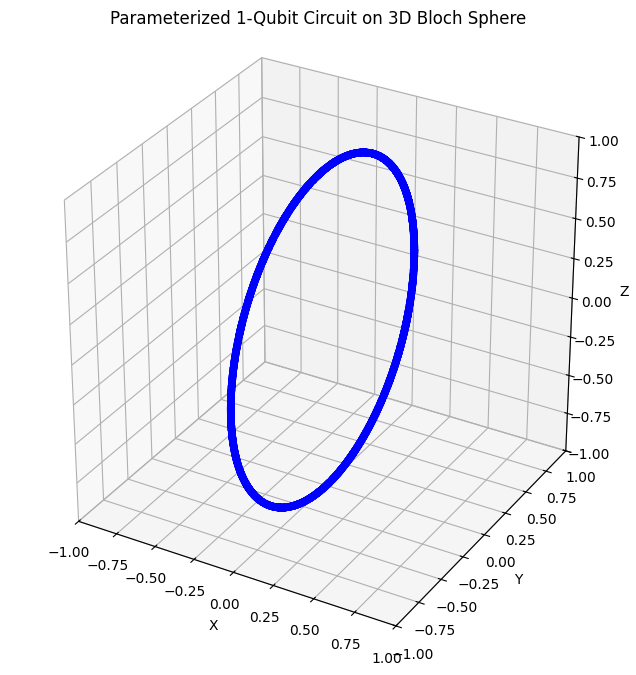

In [33]:
# List to store Bloch Sphere XZ coordinates
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create a circuit and bind parameters
    qc = ansatz1
    bound_qc = qc.assign_parameters({theta: theta_vals[i]})  # , lam: lam_vals[i]})
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)

    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])  # Store X, Z components

# Convert to a numpy array for plotting
bloch_vectors = np.array(bloch_vectors)

plot_bloch(bloch_vectors)

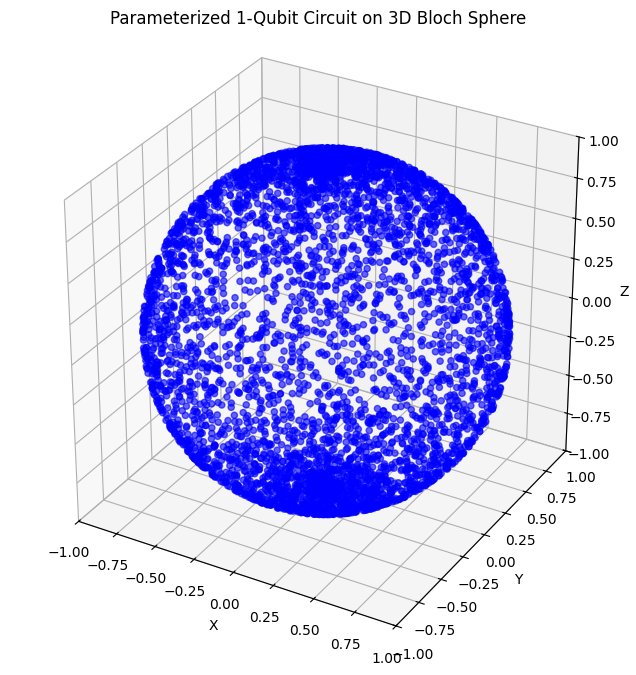

In [34]:
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create circuit and bind parameters
    qc = ansatz2
    bound_qc = qc.assign_parameters(
        {theta: theta_vals[i], phi: phi_vals[i]}
    )  # , lam: lam_vals[i]})
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)

    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])  # Store X, Z components

# Convert to numpy array for plotting
bloch_vectors = np.array(bloch_vectors)

plot_bloch(bloch_vectors)

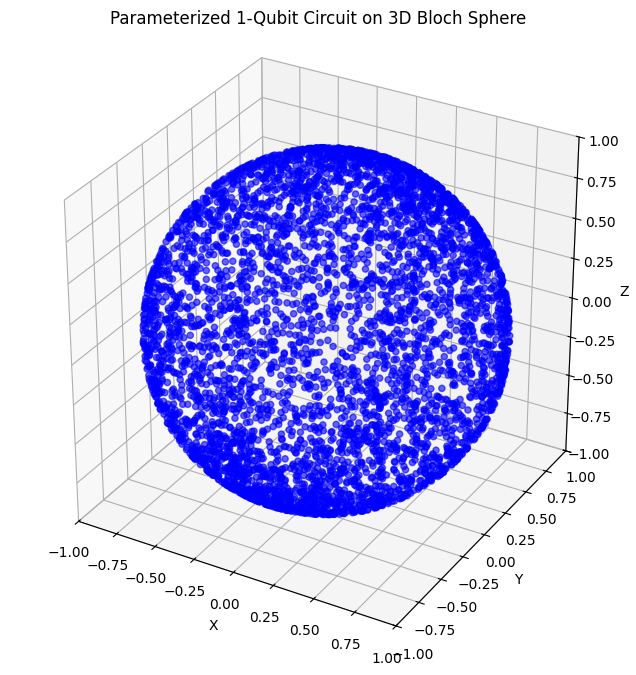

In [35]:
bloch_vectors = []

# Generate quantum states and extract Bloch vectors
for i in range(num_samples):
    # Create circuit and bind parameters
    qc = ansatz3
    bound_qc = qc.assign_parameters(
        {theta: theta_vals[i], phi: phi_vals[i], lam: lam_vals[i]}
    )
    state = Statevector.from_instruction(bound_qc)
    rho = DensityMatrix(state)

    X = rho.expectation_value(Pauli("X")).real
    Y = rho.expectation_value(Pauli("Y")).real
    Z = rho.expectation_value(Pauli("Z")).real
    bloch_vectors.append([X, Y, Z])  # Store X, Z components

# Convert to numpy array for plotting
bloch_vectors = np.array(bloch_vectors)

plot_bloch(bloch_vectors)

This circuit has  3 parameters


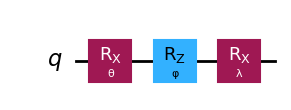

In [36]:
# Pre-defined ansatz circuit and operator class for Hamiltonian

ansatz = ansatz3

num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")

ansatz.draw("mpl", style="iqp")

In [37]:
Hamiltonian_isa = Hamiltonian.apply_layout(layout=ansatz.layout)

In [38]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

In [39]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def quantum_random_bits(n_bits):
    sim = AerSimulator()
    qc = QuantumCircuit(n_bits, n_bits)
    qc.h(range(n_bits))
    qc.measure(range(n_bits), range(n_bits))

    result = sim.run(qc, shots=1, memory=True).result()
    return result.get_memory()[0]


def quantum_random_params(n_params, bits_per_param=16, low=0.0, high=2 * np.pi):
    total_bits = n_params * bits_per_param
    bitstring = quantum_random_bits(total_bits)

    params = []
    max_int = (2**bits_per_param) - 1
    for i in range(n_params):
        chunk = bitstring[i * bits_per_param : (i + 1) * bits_per_param]
        int_val = int(chunk, 2)
        unit_val = int_val / max_int
        param = low + unit_val * (high - low)
        params.append(param)

    return params, bitstring

In [40]:
x0, x0_bits = quantum_random_params(ansatz.num_parameters)
print("Random bitstring for x0:", x0_bits)
print("x0 =", x0)

Random bitstring for x0: 011101111010011111011001011100101000110101110100
x0 = [2.93675515593527, 5.336992344693047, 3.4718349941800137]


In [41]:
# QPU Est. 2min for ibm_brisbane

from scipy.optimize import minimize
from qiskit_ibm_runtime import Batch

batch = Batch(backend=backend)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(mode=batch)
estimator.options.default_shots = 10000

res = minimize(
    cost_func,
    x0,
    args=(ansatz, Hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 10, "tol": 0.01},
)

batch.close()

Iters. done: 1 [Current cost: -0.4052013]
Iters. done: 2 [Current cost: -0.20417849999999999]
Iters. done: 3 [Current cost: -0.46327559999999995]
Iters. done: 4 [Current cost: -0.46421759999999995]
Iters. done: 5 [Current cost: -0.3059616]
Iters. done: 6 [Current cost: -0.461109]
Iters. done: 7 [Current cost: -0.46789139999999996]
Iters. done: 8 [Current cost: -0.4599786]
Iters. done: 9 [Current cost: -0.4678443]
Iters. done: 10 [Current cost: -0.46247489999999997]


In [42]:
h_vqe = res.fun
print("The reference ground state energy is ", min(eigenvalues))
print("The computed ground state energy is ", h_vqe)

The reference ground state energy is  (-0.471+0j)
The computed ground state energy is  -0.46789139999999996


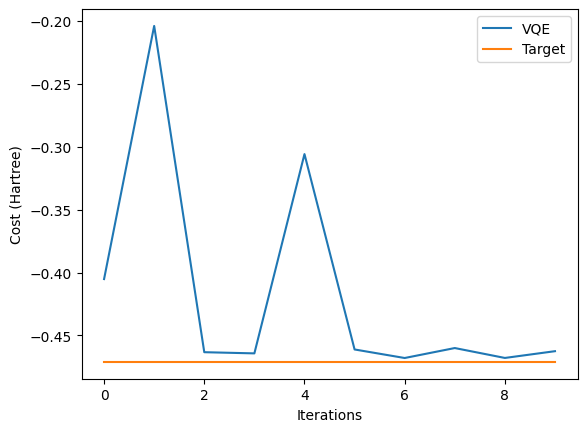

In [43]:
fig, ax = plt.subplots()
x = np.linspace(0, 10, 10)

# Define the constant function
y_constant = np.full_like(x, h)
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()

In [44]:
h2_hamiltonian = SparsePauliOp.from_list(
    [("I", -1.04886087), ("Z", -0.7967368), ("X", 0.18121804)]
)

# exact ground state energy of hamiltonian
nuclear_repulsion = 0.71997
A = np.array(h2_hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Electronic ground state energy (Hartree): ", min(eigenvalues).real)
print("Nuclear repulsion energy (Hartree): ", nuclear_repulsion)
print(
    "Total ground state energy (Hartree): ", min(eigenvalues).real + nuclear_repulsion
)
h2 = min(eigenvalues).real + nuclear_repulsion

Electronic ground state energy (Hartree):  -1.8659468547627318
Nuclear repulsion energy (Hartree):  0.71997
Total ground state energy (Hartree):  -1.1459768547627318


In [45]:
h2_hamiltonian_isa = h2_hamiltonian.apply_layout(layout=ansatz.layout)

In [46]:
x0, x0_bits_h2 = quantum_random_params(ansatz.num_parameters)
print("Random bitstring for H2 x0:", x0_bits_h2)
print("x0 =", x0)

Random bitstring for H2 x0: 000010111101101110000100000110100000010100001110
x0 = [0.29098142072617755, 3.2423096165133023, 0.12406258926513136]


In [47]:
# QPU time 4min for ibm_brisbane
batch = Batch(backend=backend)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(mode=batch)
estimator.options.default_shots = 10000

res = minimize(
    cost_func,
    x0,
    args=(ansatz, h2_hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 15},
)

batch.close()

Iters. done: 1 [Current cost: -0.3063190624719999]
Iters. done: 2 [Current cost: -0.890277196592]
Iters. done: 3 [Current cost: -1.602341811568]
Iters. done: 4 [Current cost: -1.06974519592]
Iters. done: 5 [Current cost: -1.773731200184]
Iters. done: 6 [Current cost: -1.797951242128]
Iters. done: 7 [Current cost: -1.168144079752]
Iters. done: 8 [Current cost: -1.593961503568]
Iters. done: 9 [Current cost: -1.682984000408]
Iters. done: 10 [Current cost: -1.6317331341680001]
Iters. done: 11 [Current cost: -1.7441474047519998]
Iters. done: 12 [Current cost: -1.837602586576]
Iters. done: 13 [Current cost: -1.7941451480719999]
Iters. done: 14 [Current cost: -1.846232950152]
Iters. done: 15 [Current cost: -1.849919214376]


In [48]:
h2_vqe = res.fun + nuclear_repulsion
print(
    "The reference ground state energy is ", min(eigenvalues).real + nuclear_repulsion
)
print("The computed ground state energy is ", h2_vqe)

The reference ground state energy is  -1.1459768547627318
The computed ground state energy is  -1.129949214376


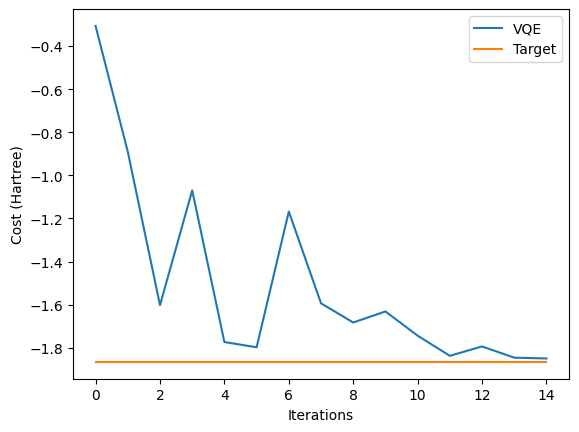

In [49]:
fig, ax = plt.subplots()
x = np.linspace(0, 5, 15)

# Define the constant function
y_constant = np.full_like(x, min(eigenvalues))
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()

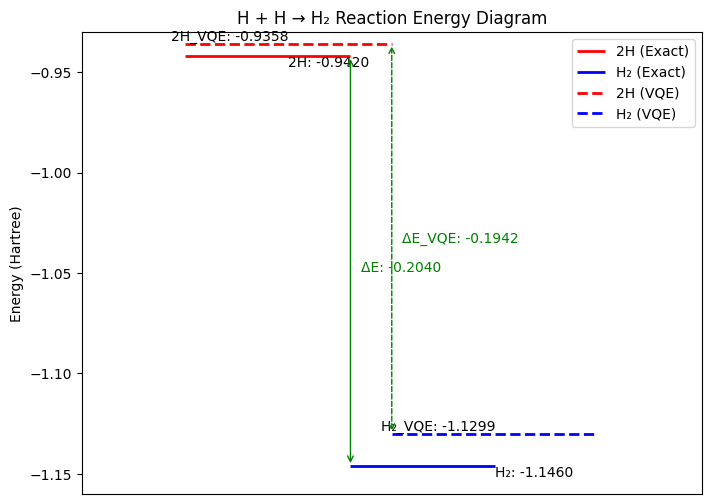

In [50]:
# Theoretical values
E_H_theo = h.real
E_H2_theo = h2

# Experimental values
E_H_exp = h_vqe
E_H2_exp = h2_vqe

# Calculate reaction energies
E_reaction_theo = E_H2_theo - (2 * E_H_theo)
E_reaction_exp = E_H2_exp - (2 * E_H_exp)

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 3)
ax.set_ylim(-1.16, -0.93)  # Adjust y-axis range to highlight differences
ax.set_xticks([])
ax.set_ylabel("Energy (Hartree)")
ax.set_title("H + H → H₂ Reaction Energy Diagram")

# Plot theoretical energy levels
ax.hlines(
    y=2 * E_H_theo, xmin=0.5, xmax=1.3, linewidth=2, color="r", label="2H (Exact)"
)
ax.hlines(y=E_H2_theo, xmin=1.3, xmax=2, linewidth=2, color="b", label="H₂ (Exact)")

# Plot experimental energy levels
ax.hlines(
    y=2 * E_H_exp,
    xmin=0.5,
    xmax=1.5,
    linewidth=2,
    color="r",
    linestyle="dashed",
    label="2H (VQE)",
)
ax.hlines(
    y=E_H2_exp,
    xmin=1.5,
    xmax=2.5,
    linewidth=2,
    color="b",
    linestyle="dashed",
    label="H₂ (VQE)",
)

# Add labels
ax.text(
    1,
    2 * E_H_theo,
    f"2H: {2*E_H_theo:.4f}",
    verticalalignment="top",
    horizontalalignment="left",
)
ax.text(
    2,
    E_H2_theo,
    f"H₂: {E_H2_theo:.4f}",
    verticalalignment="top",
    horizontalalignment="left",
)
ax.text(
    1,
    2 * E_H_exp,
    f"2H_VQE: {2*E_H_exp:.4f}",
    verticalalignment="bottom",
    horizontalalignment="right",
)
ax.text(
    2,
    E_H2_exp,
    f"H₂_VQE: {E_H2_exp:.4f}",
    verticalalignment="bottom",
    horizontalalignment="right",
)

# Add arrows for reaction energy with ΔE label in the middle
mid_y_theo = (2 * E_H_theo + E_H2_theo) / 2
mid_y_exp = (2 * E_H_exp + E_H2_exp) / 2
ax.annotate(
    "",
    xy=(1.3, E_H2_theo),
    xytext=(1.3, 2 * E_H_theo),
    arrowprops=dict(arrowstyle="<->", color="g"),
)
ax.text(
    1.35, mid_y_theo, f"ΔE: {E_reaction_theo:.4f}", color="g", verticalalignment="top"
)

ax.annotate(
    "",
    xy=(1.5, E_H2_exp),
    xytext=(1.5, 2 * E_H_exp),
    arrowprops=dict(arrowstyle="<->", color="g", linestyle="dashed"),
)
ax.text(
    1.55,
    mid_y_exp,
    f"ΔE_VQE: {E_reaction_exp:.4f}",
    color="g",
    verticalalignment="center",
)

# Add legend
ax.legend()

plt.show()

Random generator

In [51]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def quantum_random_bits(n_bits=32):
    sim = AerSimulator()
    bits = []

    for _ in range(n_bits):
        qc = QuantumCircuit(1, 1)
        qc.h(0)              # put qubit in superposition
        qc.measure(0, 0)     # collapse to 0 or 1

        result = sim.run(qc, shots=1, memory=True).result()
        bit = result.get_memory()[0]   # '0' or '1'
        bits.append(bit)

    return "".join(bits)

random_bits = quantum_random_bits(64)
print(random_bits)
print(int(random_bits, 2))

1111000001010010101001111110011011110011000010111011110111101010
17317088127554928106


## Exercise 2 - True random optimizer
Use the quantum random bit generator to perform **random search** (not COBYLA) and compare efficiency against the COBYLA result for the H Hamiltonian.

In [52]:
import time
import numpy as np
from qiskit_ibm_runtime import Batch


def quantum_random_angle(bits_per_angle=16):
    bitstring = quantum_random_bits(bits_per_angle)
    value = int(bitstring, 2) / (2**bits_per_angle)
    return 2 * np.pi * value


def quantum_random_params(n_params, bits_per_angle=16):
    return np.array([quantum_random_angle(bits_per_angle) for _ in range(n_params)])


def random_search_vqe(ansatz, hamiltonian, backend, n_trials=30, shots=10000):
    """True random optimizer: sample random parameter vectors, keep the best."""
    batch = Batch(backend=backend)
    estimator = Estimator(mode=batch)
    estimator.options.default_shots = shots

    best_energy = np.inf
    best_params = None
    energy_history = []

    start = time.time()
    for _ in range(n_trials):
        params = quantum_random_params(ansatz.num_parameters)
        pub = (ansatz, [hamiltonian], [params])
        energy = estimator.run(pubs=[pub]).result()[0].data.evs[0]
        energy_history.append(float(energy))

        if energy < best_energy:
            best_energy = float(energy)
            best_params = params

    runtime_s = time.time() - start
    batch.close()

    return {
        "best_energy": best_energy,
        "best_params": best_params,
        "energy_history": energy_history,
        "trials": n_trials,
        "shots": shots,
        "runtime_s": runtime_s,
    }


# Compare on the H Hamiltonian (same target as earlier COBYLA section)
random_result_h = random_search_vqe(
    ansatz=ansatz,
    hamiltonian=Hamiltonian_isa,
    backend=backend,
    n_trials=30,
    shots=10000,
)

random_best_h = random_result_h["best_energy"]
random_error_h = abs(random_best_h - h)
cobyla_error_h = abs(h_vqe - h)

print(f"Random search best energy: {random_best_h:.6f} hartree")
print(f"COBYLA best energy       : {h_vqe:.6f} hartree")
print(f"Exact energy             : {h:.6f} hartree")
print(f"Random search error      : {random_error_h:.6f} hartree")
print(f"COBYLA error             : {cobyla_error_h:.6f} hartree")
print(f"Random trials            : {random_result_h['trials']}")
print(f"Random runtime           : {random_result_h['runtime_s']:.2f} s")

Random search best energy: -0.466054 hartree
COBYLA best energy       : -0.467891 hartree
Exact energy             : -0.471000 hartree
Random search error      : 0.004945 hartree
COBYLA error             : 0.003109 hartree
Random trials            : 30
Random runtime           : 4.03 s


In [53]:
if random_error_h < cobyla_error_h:
    better = "random search"
else:
    better = "COBYLA"

conclusion_text = (
    f"Conclusion (Exercise 2): For this VQE instance, {better} is more efficient in terms of final energy accuracy. "
    f"Random search reached {random_best_h:.6f} hartree (error {random_error_h:.6f}), while COBYLA reached {h_vqe:.6f} hartree "
    f"(error {cobyla_error_h:.6f}). Random search used {random_result_h['trials']} random evaluations."
)

print(conclusion_text)

Conclusion (Exercise 2): For this VQE instance, COBYLA is more efficient in terms of final energy accuracy. Random search reached -0.466054 hartree (error 0.004945), while COBYLA reached -0.467891 hartree (error 0.003109). Random search used 30 random evaluations.
